<a href="https://colab.research.google.com/github/VSLolla2898/VeritasAI-2025-26/blob/main/EDA_with_TimeSeries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import kagglehub
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Download latest version
path = kagglehub.dataset_download("shadmanrohan/collisionavoidancechallenge")

print("Path to dataset files:", path)

100%|██████████| 107M/107M [00:01<00:00, 109MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/shadmanrohan/collisionavoidancechallenge/versions/1


In [3]:
os.chdir(path)
os.listdir(path)

['train_data.csv', 'test_data.csv']

In [4]:
df = pd.read_csv('train_data.csv')
print(df.head())

   event_id  time_to_tca  mission_id       risk  max_risk_estimate  \
0         0     1.566798           5 -10.204955          -7.834756   
1         0     1.207494           5 -10.355758          -7.848937   
2         0     0.952193           5 -10.345631          -7.847406   
3         0     0.579669           5 -10.337809          -7.845880   
4         0     0.257806           5 -10.391260          -7.852942   

   max_risk_scaling  miss_distance  relative_speed  relative_position_r  \
0          8.602101        14923.0         13792.0                453.8   
1          8.956374        14544.0         13792.0                474.3   
2          8.932195        14475.0         13792.0                474.6   
3          8.913444        14579.0         13792.0                472.7   
4          9.036838        14510.0         13792.0                478.7   

   relative_position_t  ...  t_sigma_rdot  c_sigma_rdot  t_sigma_tdot  \
0               5976.6  ...      0.147350     58.272095

Text(1.0542425094393248, 0.7020599913279624, 'Low Risk')

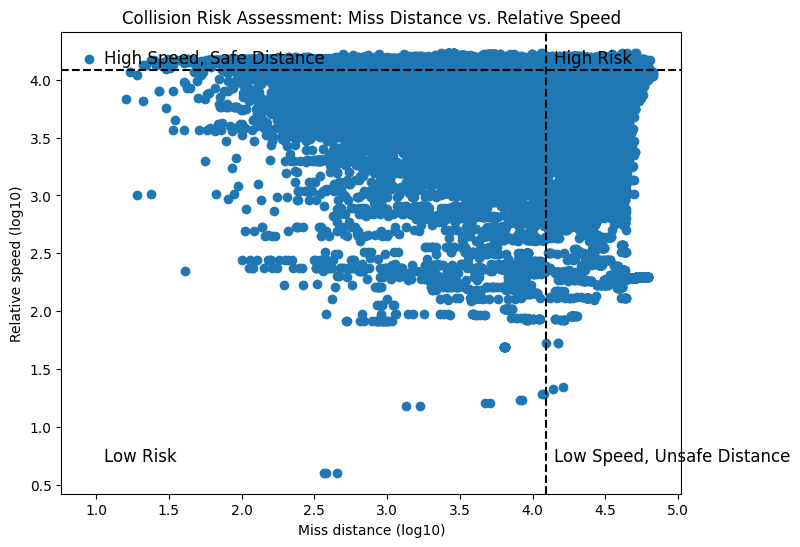

In [ ]:
# plt.scatter(np.log10(df['miss_distance']), np.log10(df['relative_speed'])) # potentially use later; add axis labels, titles, and quadrants

plt.figure(figsize=(8,6))
x = np.log10(df['miss_distance'])
y = np.log10(df['relative_speed'])

# scattering x and y, axis labels, and title
plt.scatter(x, y)
plt.xlabel("Miss distance (log10)")
plt.ylabel("Relative speed (log10)")
plt.title("Collision Risk Assessment: Miss Distance vs. Relative Speed")

xThreshold = x.median()
yThreshold = y.median()

plt.axvline(x = xThreshold, color='black', linestyle='--')
plt.axhline(y = yThreshold, color='black', linestyle='--')

plt.text(xThreshold + 0.05, yThreshold + 0.05,    "High Risk", fontsize=12)
plt.text(min(x)+0.1, yThreshold + 0.05,           "High Speed, Safe Distance", fontsize=12)
plt.text(xThreshold + 0.05, min(y) + 0.1,         "Low Speed, Unsafe Distance", fontsize=12)
plt.text(min(x)+0.1, min(y) + 0.1,                "Low Risk", fontsize=12)


In [6]:
df3 = df.copy()

In [ ]:
df3_firstEvents = df3.drop_duplicates(subset='event_id', keep='first')
df3_lastEvents = df3.drop_duplicates(subset='event_id', keep='last')

Text(1.7989700043360188, 0.7020599913279624, 'Low Risk')

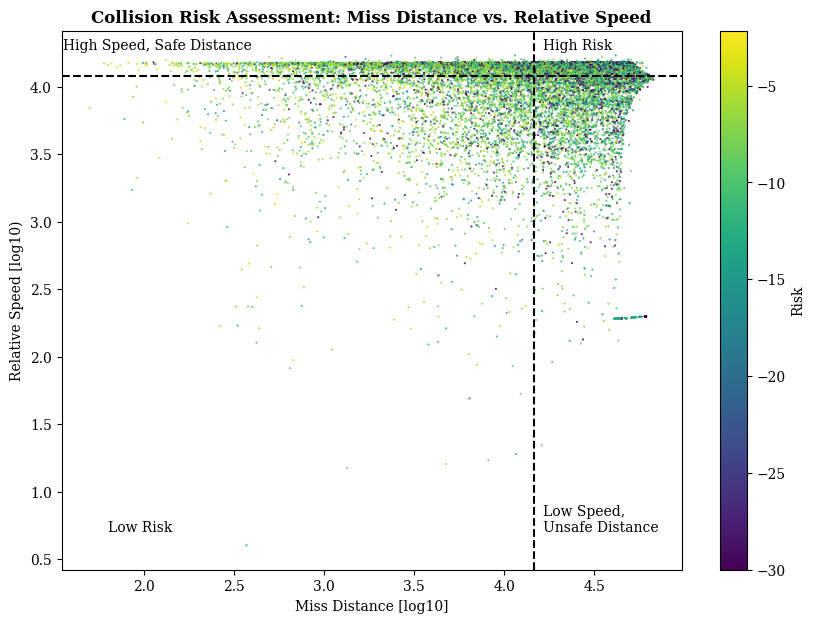

In [ ]:
# plt.scatter(np.log10(df['miss_distance']), np.log10(df['relative_speed'])) # potentially use later; add axis labels, titles, and quadrants

from matplotlib import rcParams

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['DejaVu Serif']

plt.figure(figsize=(10,7))

x = np.log10(df3_firstEvents['miss_distance'])
y = np.log10(df3_firstEvents['relative_speed'])
z = df3_firstEvents['risk']

# scattering x and y, axis labels, and title
plt.scatter(x, y, c=z, s=0.2)
plt.colorbar(label="Risk")
plt.xlabel("Miss Distance [log10]", fontsize=10)
plt.ylabel("Relative Speed [log10)", fontsize=10)
plt.title("Collision Risk Assessment: Miss Distance vs. Relative Speed", fontsize = 12, fontweight='bold')

xThreshold = x.median()
yThreshold = y.median()

plt.axvline(x = xThreshold, color='black', linestyle='--')
plt.axhline(y = yThreshold, color='black', linestyle='--')

plt.text(xThreshold + 0.05, yThreshold + 0.2,     "High Risk", fontsize=10)
plt.text(min(x)-0.15, yThreshold + 0.2,           "High Speed, Safe Distance", fontsize=10)
plt.text(xThreshold + 0.05, min(y) + 0.1,         "Low Speed,\nUnsafe Distance", fontsize=10)
plt.text(min(x)+0.1, min(y) + 0.1,                "Low Risk", fontsize=10)


Text(1.4222192947339194, 0.7020599913279624, 'Low Risk')

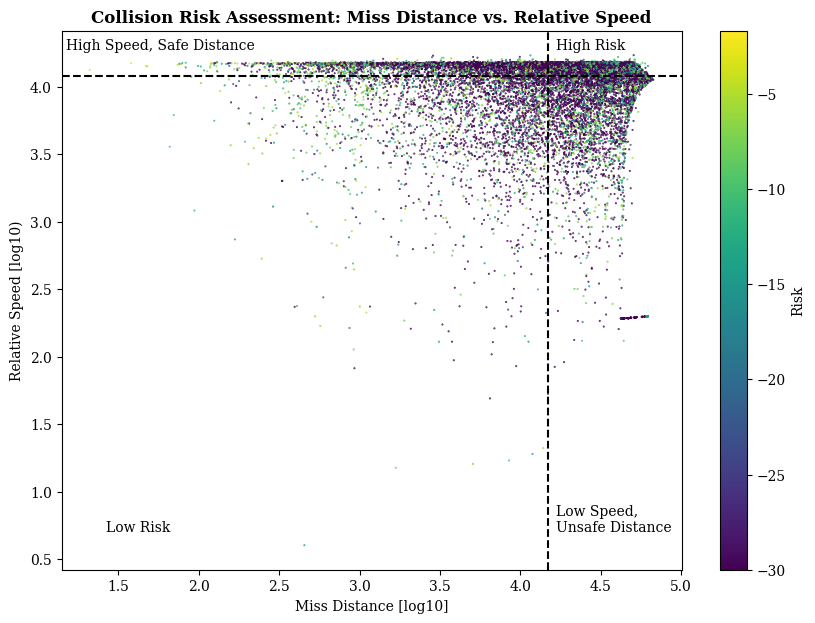

In [ ]:
# plt.scatter(np.log10(df['miss_distance']), np.log10(df['relative_speed'])) # potentially use later; add axis labels, titles, and quadrants

from matplotlib import rcParams

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['DejaVu Serif']

plt.figure(figsize=(10,7))

x = np.log10(df3_lastEvents['miss_distance'])
y = np.log10(df3_lastEvents['relative_speed'])
z = df3_lastEvents['risk']

# scattering x and y, axis labels, and title
plt.scatter(x, y, c=z, s=0.2)
plt.colorbar(label="Risk")
plt.xlabel("Miss Distance [log10]", fontsize=10)
plt.ylabel("Relative Speed [log10)", fontsize=10)
plt.title("Collision Risk Assessment: Miss Distance vs. Relative Speed", fontsize = 12, fontweight='bold')

xThreshold = x.median()
yThreshold = y.median()

plt.axvline(x = xThreshold, color='black', linestyle='--')
plt.axhline(y = yThreshold, color='black', linestyle='--')

plt.text(xThreshold + 0.05, yThreshold + 0.2,     "High Risk", fontsize=10)
plt.text(min(x)-0.15, yThreshold + 0.2,           "High Speed, Safe Distance", fontsize=10)
plt.text(xThreshold + 0.05, min(y) + 0.1,         "Low Speed,\nUnsafe Distance", fontsize=10)
plt.text(min(x)+0.1, min(y) + 0.1,                "Low Risk", fontsize=10)


In [ ]:
df2 = df.copy()

eventIDs = np.array(df2['event_id']#.head(100)
    )

uniqueEventIDs = np.unique(eventIDs)

for i in uniqueEventIDs[:5]:
  location = np.where(eventIDs == i)[0]

  for j in range(1, len(location)):
    for k in df.columns:
      df2[f'{k}{j}'] = df[k][j]
      #break
    #break

  #del df[k][j]
  df2 = df2.drop(index=location[1:])

#df['time_to_tca'].head(6)

In [ ]:
print(df.shape)
print(df2.shape)

(162634, 103)
(162580, 2163)


In [ ]:
df['event_id'].head(50)
#len(uniqueEventIDs)

,event_id
0,0
1,0
2,0
3,0
4,0
5,1
6,1
7,1
8,1
9,2


In [ ]:
np.mean(df['relative_velocity_n'])

np.float64(-54.009079897192464)

<Axes: >

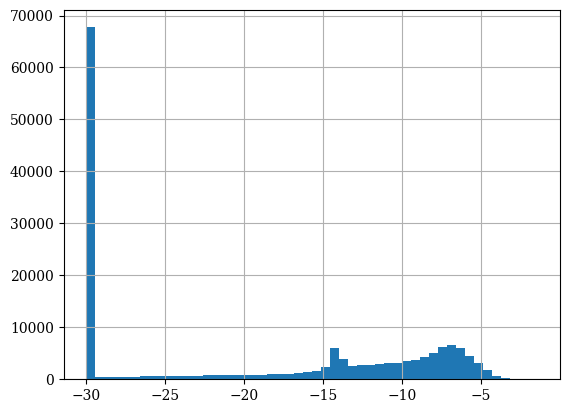

In [ ]:
# risk
df['risk'].hist(bins = 50)
#np.log10(abs(df['risk'])).hist(bins = 50)

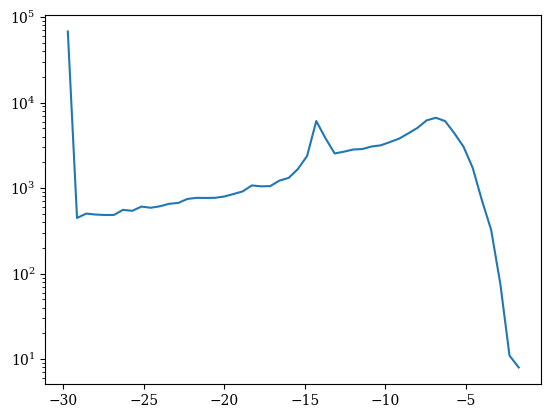

In [ ]:
counts, binEdges = np.histogram(df['risk'], bins=50)
binCenters = (binEdges[1:] + binEdges[:-1]) / 2
plt.plot(binCenters, counts)
plt.yscale("log")

In [ ]:
print(min(counts))
print(max(counts))

8
67740


<Axes: >

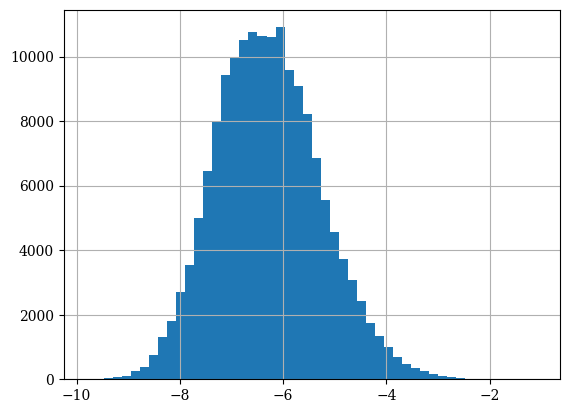

In [ ]:
# max risk estimate
df['max_risk_estimate'].hist(bins = 50)

<Axes: >

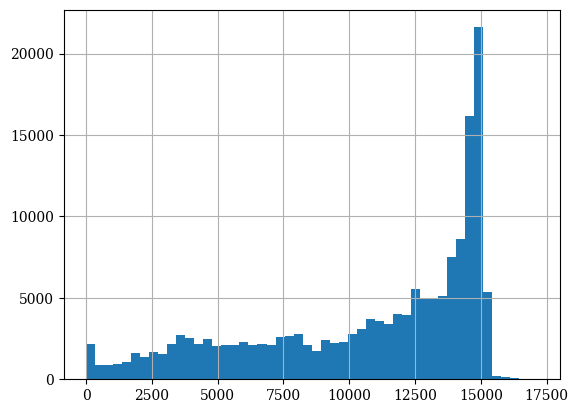

In [ ]:
# relative speed
df['relative_speed'].hist(bins = 50)

<Axes: >

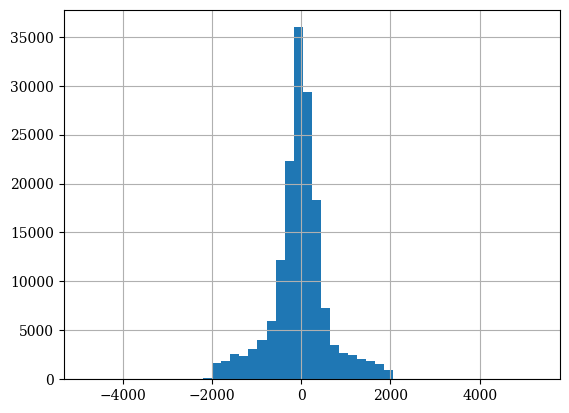

In [ ]:
# relative speed
df['relative_position_r'].hist(bins = 50) # abs makes it only 0-2000

<Axes: >

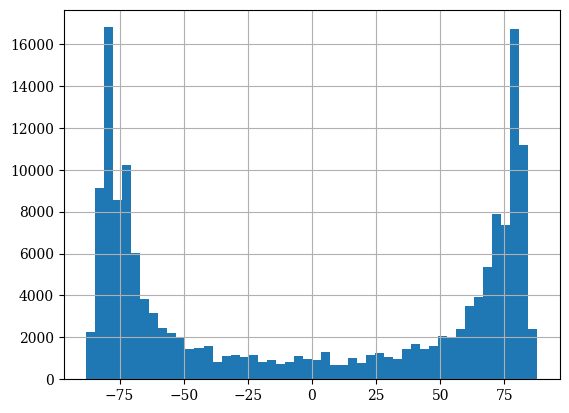

In [ ]:
# geocentric latitude
df['geocentric_latitude'].hist(bins = 50)

<Axes: >

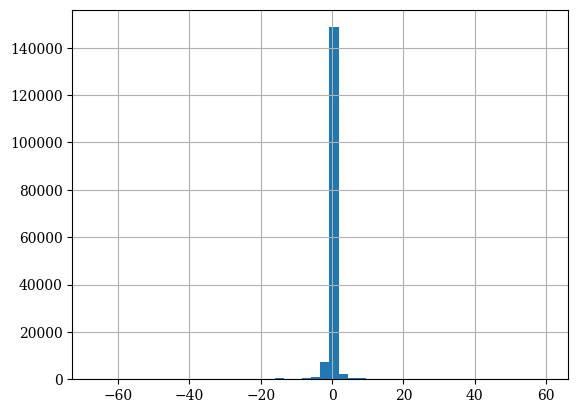

In [ ]:
# elevation
df['elevation'].hist(bins = 50) # throws error for log10 for some reason

In [ ]:
# from sklearn.model_selection import train_test_split
# from sklearn.ensemble import RandomForestClassifier

# # y = np.array(df['risk'])
# # indices1 = np.where(y < -16)
# # indices2 = np.where(y < -9)
# # indices3 = np.where(y >= -9)

# # y[indices1] = "1"
# # y[indices2] = "2"
# # y[indices3] = "3"

# y = df["risk"].values.astype(float)

# y_binned = np.empty_like(y, dtype=int)
# y_binned[y < -16] = 1
# y_binned[(y >= -16) & (y < -9)] = 2
# y_binned[y >= -9] = 3


# # x = np.array(df['miss_distance'])
# # x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=3)
# # model = RandomForestClassifier(n_estimators=100, random_state=3)
# # model.fit(x_train.reshape(-1, 1), y_train)
# # y_predict = model.predict(x_test.reshape(-1, 1))
# # print(y_predict)

# # relative_error = abs(y_predict - y_test) / y_test
# # print(np.min(relative_error))
# # print(np.max(relative_error))
# # print(np.median(relative_error))
# # print(np.mean(relative_error))
# # print(relative_error)
# # print(len(relative_error))


In [ ]:
# #random-forest analysis code

# runs = 20 #runs per feature
# results = [] #dictionary

# columns2 = [c for c in df.columns if c != "risk"] #getting all the input columns and adding them to a list
# for feature in columns2:

#   for i in range(20):

#     # what we covered in previous lesson for miss_distance
#     x = df[feature]
#     x_train, x_test, y_train, y_test = train_test_split(x, y_binned, test_size=0.2, random_state=3)
#     model = RandomForestClassifier(n_estimators=100, random_state=3)
#     model.fit(x_train.values.reshape(-1, 1), y_train)
#     y_predict = model.predict(x_test.values.reshape(-1, 1))

#     # results.append(np.mean(relative_error))
#     break

# results



ValueError: Unknown label type: continuous. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

In [ ]:
# from sklearn.metrics import accuracy_score

# runs = 20
# results = {}  # feature -> list of accuracies

# columns2 = [c for c in df.columns if c != "risk"]

# for feature in columns2:

#     accuracies = []

#     x = df[feature].values.reshape(-1, 1)

#     for i in range(runs):
#         x_train, x_test, y_train, y_test = train_test_split(
#             x, y_binned, test_size=0.2, random_state=i
#         )

#         model = RandomForestClassifier(
#             n_estimators=100,
#             random_state=i
#         )

#         model.fit(x_train, y_train)
#         y_predict = model.predict(x_test)

#         acc = accuracy_score(y_test, y_predict)
#         accuracies.append(acc)

#     results[feature] = accuracies


# rows = []
# for feature, accs in results.items():
#     for acc in accs:
#         rows.append({"feature": feature, "accuracy": acc})

# acc_df = pd.DataFrame(rows)
# acc_df.to_csv("single_feature_rf_accuracies.csv", index=False)

KeyboardInterrupt: 

In [5]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [41]:
SAVE_PATH = "/content/drive/MyDrive/double_feature_RF.csv"

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [43]:
y = df["risk"].values.astype(float)

yCategories = np.empty_like(y, dtype=int)
yCategories[y < -16] = 1
yCategories[(y >= -16) & (y < -9)] = 2
yCategories[y >= -9] = 3

In [44]:
# # SF
# if os.path.exists(SAVE_PATH):
#     acc_df = pd.read_csv(SAVE_PATH)
#     completed_features = set(acc_df["feature"].unique())
#     print(f"Resuming — {len(completed_features)} features already done")
# else:
#     acc_df = pd.DataFrame(columns=["feature", "accuracy"])
#     completed_features = set()

# DF
if os.path.exists(SAVE_PATH):
    accuracyDF = pd.read_csv(SAVE_PATH)
    finishedPairs = set(zip(accuracyDF["feature1"], accuracyDF["feature2"]))
    print(f"Resuming — {len(finishedPairs)} pairs already done")
else:
    accuracyDF = pd.DataFrame(columns=["feature1", "feature2", "accuracy"])
    finishedPairs = set()

In [45]:
from itertools import combinations

In [ ]:

# feature_columns = [c for c in df.columns if c == "relative_velocity_n"]
# # feature_columns = [c for c in df.columns if c != "risk" and c != "event_id" and c != "mission_id" and c != "max_risk_estimate" and c != "max_risk_scaling" c != "c_object_type" and c !="t_position_covariance_det" and c !="c_position_covariance_det"]
# #columns2 = [c for c in df.columns if c == "t_sigma_r" or c == "c_sigma_r" or c == "t_sigma_t" or c == "c_sigma_t" or c == "t_sigma_n" or c=="c_sigma_n" or c=="t_sigma_rdot" or c=="c_sigma_rdot" or c=="t_sigma_tdot" or c=="c_sigma_tdot" or c=="t_sigma_ndot" or c=="c_sigma_ndot" or c=="F10" or c=="F3M" or c=="SSN" or c=="AP"]
# for feature in feature_columns:

#     if feature in completed_features:
#         continue  # skip already finished features

#     print(f"Started: {feature}")

#     X = df[feature].values.reshape(-1, 1)
#     # mask = ~np.isnan(X).ravel()
#     # X = X[mask]
#     # y = y_binned[mask]

#     accuracies = []

#     for i in range(10):
#         #starttime = time.time()
#         X_train, X_test, y_train, y_test = train_test_split(
#             X, y_binned, test_size=0.2, random_state=i
#         )

#         model = RandomForestClassifier(
#             n_estimators=25,
#             random_state=i,
#             max_depth=75
#         )


#         model.fit(X_train, y_train)
#         y_pred = model.predict(X_test)

#         acc = accuracy_score(y_test, y_pred)
#         accuracies.append(acc)

#     feature_df = pd.DataFrame({
#         "feature": [feature] * 10,
#         "accuracy": accuracies
#     })

#     acc_df = pd.concat([acc_df, feature_df], ignore_index=True)
#     acc_df.to_csv(SAVE_PATH, index=False)

#     #endtime = time.time()

#     print(f"Completed: {feature}")
#     # print(f"Elapsed: {endtime - starttime:.8f}")

# double feature RF analysis
columns3 = [
    c for c in df.columns
    if c == "c_j2k_inc" or c== "c_cd_area_over_mass" or c== "azimuth" or c=="c_sedr" or c=="c_cr_area_over_mass" or c== "relative_velocity_n" or c=="relative_velocity_t" or c=="c_h_per" or c =="c_j2k_sma" or c== "t_j2k_inc" or c=="c_h_apo" or c=="t_j2k_sma" or c=="c_j2k_ecc" or c=="elevation" or c=="c_sigma_ndot" or c=="c_sigma_n" or c =="relative_speed" or c=="geocentric_latitude" or c=="c_sigma_tdot" or c=="t_h_per" or c=="miss_distance"
] # using top 20 features from the single-feature analysis + miss_distance

# combinations was recommended by chatGPT to not repeat pairs
for f1, f2 in combinations(columns3, 2):

    if (f1, f2) in finishedPairs:
        continue

    print(f"starting ({f1}, {f2})")

    x = df[[f1, f2]].values
    accuracies = []

    for i in range(10): #10 trials per feature
        x_train, x_test, y_train, y_test = train_test_split(x, y_binned, test_size=0.2, random_state=i)
        model = RandomForestClassifier(n_estimators=12,random_state=i, n_jobs=-1)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        accuracies.append(accuracy_score(y_test, y_pred))

    pairDF = pd.DataFrame({
        "feature1": [f1] * 10,
        "feature2": [f2] * 10,
        "accuracy": accuracies
    })

    accuracyDF = pd.concat([accuracyDF, pairDF], ignore_index=True)
    accuracyDF.to_csv(SAVE_PATH, index=False)

    print(f"finished ({f1}, {f2})")

In [ ]:
SAVE_PATH = "/content/drive/MyDrive/single_feature_RF2.csv"
df = pd.read_csv(SAVE_PATH)#220/350

#code from chatGPT; allows grouped lists to be within the main list
accuracyScoreList = [
    group["accuracy"].tolist()
    for _, group in df.groupby("feature")
]
avgAccuracies = [sum(lst) / len(lst) for lst in accuracyScoreList]
accuracyScoreList

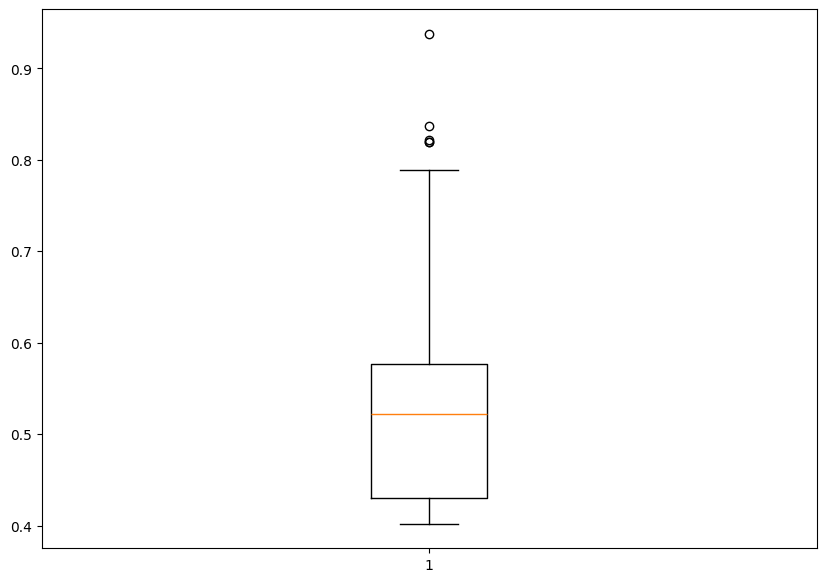

In [12]:
# box and whisker plot code
d = np.random.normal(100, 20, 200)
fig = plt.figure(figsize =(10, 7))
plt.boxplot(avgAccuracies)
plt.show()

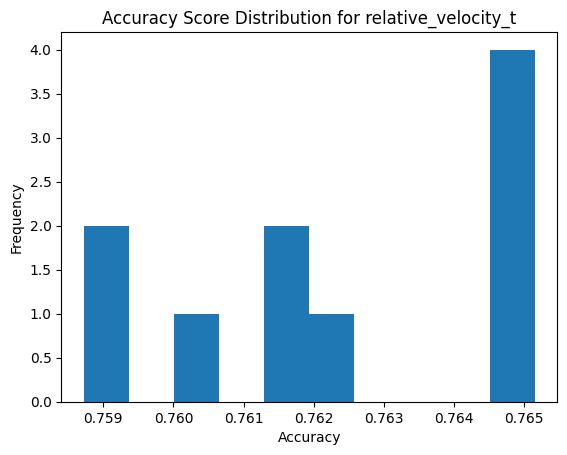

In [32]:
# historgams

vals = [0.7645955668,
0.7614904541,
0.7651182095,
0.7588464968,
0.758723522,
0.7621360716,
0.7618286347,
0.7651489532,
0.7603529376,
0.7650567221]

plt.hist(vals, bins=10)
plt.xlabel("Accuracy")
plt.ylabel("Frequency")
plt.title("Accuracy Score Distribution for relative_velocity_t")
plt.show()
